## Logistic Regression with python  

**Objectives**  
After completing this we will able to:  
**.** Use Logistic Regression for classification  
**.** Preprocess data for modeling  
**.** Implement Logistic regression on real world data 

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import log_loss

In [58]:
import warnings
warnings.filterwarnings('ignore')

### Classification with `logistic` ` regression`

### Scenario  

Assume that you are working for a telecommunications company which is concerned about the number of customers leaving their land-line business for cable competitors. They need to understand who is more likely to leave the company.

### About the dataset  
We will use a telecommunications dataset for predicting customer churn. This is a historical customer dataset where each row represents one customer. The data is relatively easy to understand, and you may uncover insights you can use immediately. Typically it is less expensive to keep customers than acquire new ones, so the focus of this analysis is to predict the customers who will stay with the company.

This data set provides you information about customer preferences, services opted, personal details, etc. which helps you predict customer churn.

#### Load dataset

In [59]:
churn_df = pd.read_csv('ChurnDataset.csv')

In [60]:
churn_df

,tenure,age,address,income,ed,employ,equip,callcard,wireless,longmon,...,pager,internet,callwait,confer,ebill,loglong,logtoll,lninc,custcat,churn
0,11.0,33.0,7.0,136.0,5.0,5.0,0.0,1.0,1.0,4.40,...,1.0,0.0,1.0,1.0,0.0,1.482,3.033,4.913,4.0,1.0
1,33.0,33.0,12.0,33.0,2.0,0.0,0.0,0.0,0.0,9.45,...,0.0,0.0,0.0,0.0,0.0,2.246,3.240,3.497,1.0,1.0
2,23.0,30.0,9.0,30.0,1.0,2.0,0.0,0.0,0.0,6.30,...,0.0,0.0,0.0,1.0,0.0,1.841,3.240,3.401,3.0,0.0
3,38.0,35.0,5.0,76.0,2.0,10.0,1.0,1.0,1.0,6.05,...,1.0,1.0,1.0,1.0,1.0,1.800,3.807,4.331,4.0,0.0
4,7.0,35.0,14.0,80.0,2.0,15.0,0.0,1.0,0.0,7.10,...,0.0,0.0,1.0,1.0,0.0,1.960,3.091,4.382,3.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,55.0,44.0,24.0,83.0,1.0,23.0,0.0,1.0,0.0,17.35,...,0.0,0.0,0.0,1.0,0.0,2.854,3.199,4.419,3.0,0.0
196,34.0,23.0,3.0,24.0,1.0,7.0,0.0,1.0,0.0,6.00,...,0.0,0.0,1.0,1.0,0.0,1.792,3.332,3.178,3.0,0.0
197,6.0,32.0,10.0,47.0,1.0,10.0,0.0,1.0,0.0,3.85,...,0.0,0.0,1.0,1.0,0.0,1.348,3.168,3.850,3.0,0.0
198,24.0,30.0,0.0,25.0,4.0,5.0,0.0,1.0,1.0,8.70,...,1.0,1.0,1.0,1.0,1.0,2.163,3.866,3.219,4.0,1.0


### Data Preprocessing  
We can use a subset of the fields available to develop out model. Let us assume that the fields we use are 'tenure', 'age', 'address', 'income', 'ed', 'employ', 'equip' and of course 'churn'.

In [61]:
churn_df = churn_df[['tenure', 'age', 'address', 'income', 'ed', 'employ', 'equip', 'churn']]
churn_df['churn'] = churn_df['churn'].astype('int')
churn_df

,tenure,age,address,income,ed,employ,equip,churn
0,11.0,33.0,7.0,136.0,5.0,5.0,0.0,1
1,33.0,33.0,12.0,33.0,2.0,0.0,0.0,1
2,23.0,30.0,9.0,30.0,1.0,2.0,0.0,0
3,38.0,35.0,5.0,76.0,2.0,10.0,1.0,0
4,7.0,35.0,14.0,80.0,2.0,15.0,0.0,0
...,...,...,...,...,...,...,...,...
195,55.0,44.0,24.0,83.0,1.0,23.0,0.0,0
196,34.0,23.0,3.0,24.0,1.0,7.0,0.0,0
197,6.0,32.0,10.0,47.0,1.0,10.0,0.0,0
198,24.0,30.0,0.0,25.0,4.0,5.0,0.0,1


as we have selected 8 columns and also convert the target column `churn` from float to integer

**For modeling** the input fields `X` and the target field `y` need to be fixed. Since that the target to be predicted is `churn`, the data under this field will be stored under the variable `y`. We may use any combination or all of the remaining fields as the input. Store these values in the variable `X`.

In [62]:
X = np.asarray(churn_df[['tenure', 'age', 'address', 'income', 'ed', 'employ', 'equip']])
X[0:5]  # print the 1st 5 values

array([[ 11.,  33.,   7., 136.,   5.,   5.,   0.],
       [ 33.,  33.,  12.,  33.,   2.,   0.,   0.],
       [ 23.,  30.,   9.,  30.,   1.,   2.,   0.],
       [ 38.,  35.,   5.,  76.,   2.,  10.,   1.],
       [  7.,  35.,  14.,  80.,   2.,  15.,   0.]])

In [63]:
y = np.asarray(churn_df[['churn']])
y[0:5]  #print the first 5 values

array([[1],
       [1],
       [0],
       [0],
       [0]])

It is also a norm to standardize or normalize the dataset in order to have all the features at the same scale. This helps the model learn faster and improves the model performance. We may make use of StandardScalar function in the Scikit-Learn library.

In [64]:
X_norm = StandardScaler().fit(X).transform(X)
X_norm[0:5] # Print the first 5 samples or arrays (rows) representing the scaled features

array([[-1.13518441, -0.62595491, -0.4588971 ,  0.4751423 ,  1.6961288 ,
        -0.58477841, -0.85972695],
       [-0.11604313, -0.62595491,  0.03454064, -0.32886061, -0.6433592 ,
        -1.14437497, -0.85972695],
       [-0.57928917, -0.85594447, -0.261522  , -0.35227817, -1.42318853,
        -0.92053635, -0.85972695],
       [ 0.11557989, -0.47262854, -0.65627219,  0.00679109, -0.6433592 ,
        -0.02518185,  1.16316   ],
       [-1.32048283, -0.47262854,  0.23191574,  0.03801451, -0.6433592 ,
         0.53441472, -0.85972695]])

### Splitting the DataSet

The trained model has to be tested and evaluated on data which has not been used during training. Therefore, it is required to separate a part of the data for testing and the remaining for training. For this, we may make use of the train_test_split function in the scikit-learn library.

In [65]:
# Split the normalized features and labels into training (80%) and testing (20%) sets
X_train,X_test,y_train,y_test = train_test_split(X_norm, y, test_size = 0.2, random_state = 4)

### Logistic Regression Classifier modeling  

Let's build the model using **`LogisticRegression`** from the Scikit-learn package and fit our model with train data set.

In [76]:
# Train Logistic Regression with strong regularization (C=0.01) and balanced weights to handle
# data imbalance, optimizing Log Loss down to ~0.592 from ~0.625
lr = LogisticRegression(C=0.01, class_weight='balanced').fit(X_train,y_train)

Fitting, or in simple terms training, gives us a model that has now learnt from the traning data and can be used to predict the output variable. Let us predict the churn parameter for the test data set.

In [77]:
# Use the trained model to predict outcomes for the unseen test features
yhat = lr.predict(X_test)
# Display the first 10 predicted class labels (0 or 1) from the test set
yhat[:10]

array([0, 0, 0, 0, 0, 0, 1, 0, 1, 0])

To understand this prediction, we can also have a look at the prediction probability of data point of the test data set. Use the function **`predict_proba`** , we can get the probability of each class. The first column is the probability of the record belonging to class 0, and second column that of class 1. Note that the class prediction system uses the threshold for class prediction as 0.5. This means that the class predicted is the one which is most likely.

In [78]:
yhat_prob = lr.predict_proba(X_test)

# Show the first 10 rows of probabilities where column 1 is for class 0 and column 2 is for class 1
yhat_prob[:10]

array([[0.50500028, 0.49499972],
       [0.58742032, 0.41257968],
       [0.52766033, 0.47233967],
       [0.62200967, 0.37799033],
       [0.52991548, 0.47008452],
       [0.51585314, 0.48414686],
       [0.46911194, 0.53088806],
       [0.58546509, 0.41453491],
       [0.33327841, 0.66672159],
       [0.62359618, 0.37640382]])

Since the purpose here is to predict the 1 class more acccurately, you can also examine what role each input feature has to play in the prediction of the 1 class. Consider the code below.

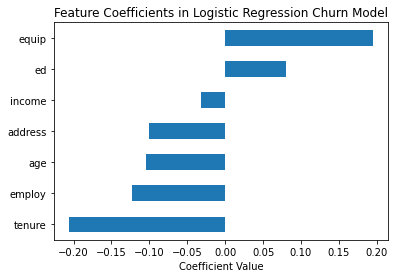

In [79]:
#Match the model coefficients to their respective feature names
coefficients = pd.Series(lr.coef_[0], index=churn_df.columns[:-1])

#Sort the values and create a horizontal bar chart
coefficients.sort_values().plot(kind='barh')

#Add titles and labels for clear visual interpretation
plt.title("Feature Coefficients in Logistic Regression Churn Model")
plt.xlabel("Coefficient Value")
plt.show()

### Log Loss  

Log loss (Logarithmic loss), also known as Binary Cross entropy loss, is a function that generates a loss value based on the class wise prediction probabilities and the actual class labels. The lower the log loss value, the better the model is considered to be.

In [80]:
log_loss(y_test, yhat_prob)

0.5925859703347849

### Confusion matrix Heatmap

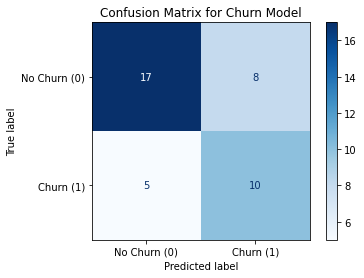

In [84]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate the confusion matrix data
cm = confusion_matrix(y_test, yhat)

# Plot the heatmap
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn (0)', 'Churn (1)'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix for Churn Model")
plt.show()

### The ROC Curve (Receiver Operating Characteristic)

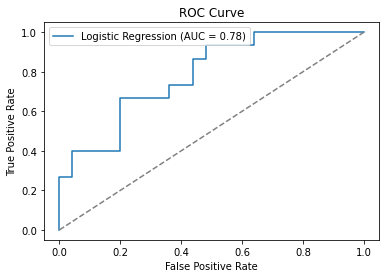

In [85]:
from sklearn.metrics import roc_curve, roc_auc_score

# Calculate false positive rate and true positive rate
fpr, tpr, thresholds = roc_curve(y_test, yhat_prob[:, 1])
auc_score = roc_auc_score(y_test, yhat_prob[:, 1])

# Plot the ROC Curve
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc_score:.2f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray') # Random guess line
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

### Probability Distribution Plot

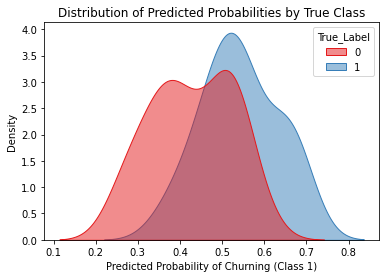

In [89]:
import seaborn as sns

# Create a dataframe by safely flattening the numpy array
prob_df = pd.DataFrame({'True_Label': y_test.ravel(), 'Prob_Churn': yhat_prob[:, 1]})

# Plot the distributions
sns.kdeplot(data=prob_df, x='Prob_Churn', hue='True_Label', fill=True, common_norm=False, palette='Set1', alpha=0.5)
plt.title("Distribution of Predicted Probabilities by True Class")
plt.xlabel("Predicted Probability of Churning (Class 1)")
plt.ylabel("Density")
plt.show()